Import all required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


Create Neural Network Class

In [2]:
class NeuralNetwork:
    def __init__ (self,
                  input_size,
                  hidden_size,
                  output_size,
                  learning_rate=0.01,
                  epochs=100):
        self.input_size=input_size
        self.hidden_size=hidden_size
        self.output_size=output_size
        self.learning_rate=learning_rate
        self.epochs=epochs

        self.W1=np.random.randn(self.input_size,self.hidden_size)*0.01
        self.b1=np.zeros((1,self.hidden_size))
        self.W2=np.random.randn(self.hidden_size,self.output_size)*0.01
        self.b2=np.zeros((1,self.output_size))

        self.loss_history=[]
        self.accuracy_history=[]
    def relu(self,z):
        return np.maximum(0,z)
    def relu_derivative(self,z):
        return np.where(z>0,1,0)
    def softmax(self,z):
        exp_values=np.exp(z-np.max(z,axis=1,keepdims=True))
        return exp_values/np.sum(exp_values,axis=1,keepdims=True)
    def forward(self,X):
        self.z1=np.dot(X,self.W1)+self.b1
        self.a1=self.relu(self.z1)
        self.z2=np.dot(self.a1,self.W2)+self.b2
        self.probs=self.softmax(self.z2)
        return self.probs
    def compute_loss(self,y_true,probs):
        loss=-np.mean(np.sum(y_true*np.log(probs),axis=1))
        return loss
    def compute_accuracy(self,y_true,probs):
        predictions=np.argmax(probs,axis=1)
        true_labels=np.argmax(y_true,axis=1)
        return np.mean(predictions==true_labels)
    def backward(self,X,y):
        m=X.shape[0]
        delta3=self.probs-y
        dW2=np.dot(self.a1.T,delta3)/m
        db2=np.sum(delta3,axis=0,keepdims=True)/m
        delta2=np.dot(delta3,self.W2.T)*self.relu_derivative(self.z1)
        dW1=np.dot(X.T,delta2)/m
        db1=np.sum(delta2,axis=0,keepdims=True)/m
        
        self.W2-=self.learning_rate*dW2
        self.W1-=self.learning_rate*dW1
        self.b2-=self.learning_rate*db2
        self.b1-=self.learning_rate*db1
    def train(self,X,y):
        for epoch in range(self.epochs):
            probs=self.forward(X)
            loss=self.compute_loss(y,probs)
            accuracy=self.compute_accuracy(y,probs)
            self.loss_history.append(loss)
            self.accuracy_history.append(accuracy)

            self.backward(X,y)
            if epoch%10==0:
              print(f"Training metrics : Epoch: {epoch},loss: {loss:.4f},accuracy: {accuracy:.4f}")

        


        
    



Step 2: Load Iris Dataset


In [3]:
iris=load_iris()

In [4]:
X=iris.data
y=iris.target

In [5]:
X.shape

(150, 4)

In [6]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [7]:
y.shape


(150,)

In [8]:
y[:5]

array([0, 0, 0, 0, 0])

Step 3: One hot Encoding

In [9]:
encoder=OneHotEncoder(sparse_output=False)
y=encoder.fit_transform(y.reshape(-1,1))

In [10]:
y.shape

(150, 3)

In [11]:
y[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120, 3)
(30, 3)


In [13]:
input_size=4
hidden_size=8
output_size=3


In [14]:
nn_iris=NeuralNetwork(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    learning_rate=0.04,
    epochs=500
)

In [15]:
nn_iris.train(X_train,y_train)

Training metrics : Epoch: 0,loss: 1.0985,accuracy: 0.5250
Training metrics : Epoch: 10,loss: 1.0982,accuracy: 0.3417
Training metrics : Epoch: 20,loss: 1.0979,accuracy: 0.3417
Training metrics : Epoch: 30,loss: 1.0973,accuracy: 0.3417
Training metrics : Epoch: 40,loss: 1.0963,accuracy: 0.3417
Training metrics : Epoch: 50,loss: 1.0944,accuracy: 0.3417
Training metrics : Epoch: 60,loss: 1.0905,accuracy: 0.4000
Training metrics : Epoch: 70,loss: 1.0828,accuracy: 0.6000
Training metrics : Epoch: 80,loss: 1.0680,accuracy: 0.6667
Training metrics : Epoch: 90,loss: 1.0411,accuracy: 0.7083
Training metrics : Epoch: 100,loss: 0.9974,accuracy: 0.6583
Training metrics : Epoch: 110,loss: 0.9331,accuracy: 0.6583
Training metrics : Epoch: 120,loss: 0.8483,accuracy: 0.6583
Training metrics : Epoch: 130,loss: 0.7546,accuracy: 0.6583
Training metrics : Epoch: 140,loss: 0.6700,accuracy: 0.6667
Training metrics : Epoch: 150,loss: 0.6028,accuracy: 0.6750
Training metrics : Epoch: 160,loss: 0.5518,accuracy

In [16]:
test_probs = nn_iris.forward(X_test)

test_loss = nn_iris.compute_loss(
    y_test,
    test_probs
)

test_accuracy = nn_iris.compute_accuracy(
    y_test,
    test_probs
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1641
Test Accuracy: 0.9667


Actual Vs Predicted

In [17]:
predictions=np.argmax(test_probs,axis=1)
actual=np.argmax(y_test,axis=1)
print('Predictions')
print(predictions)
print('\nActual')
print(actual)

Predictions
[1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Actual
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Count correct predictions

In [18]:
print(f'count of correct predictions',{(predictions==actual).sum()})
print(f'Total test samples',{len(actual)})

count of correct predictions {np.int64(29)}
Total test samples {30}


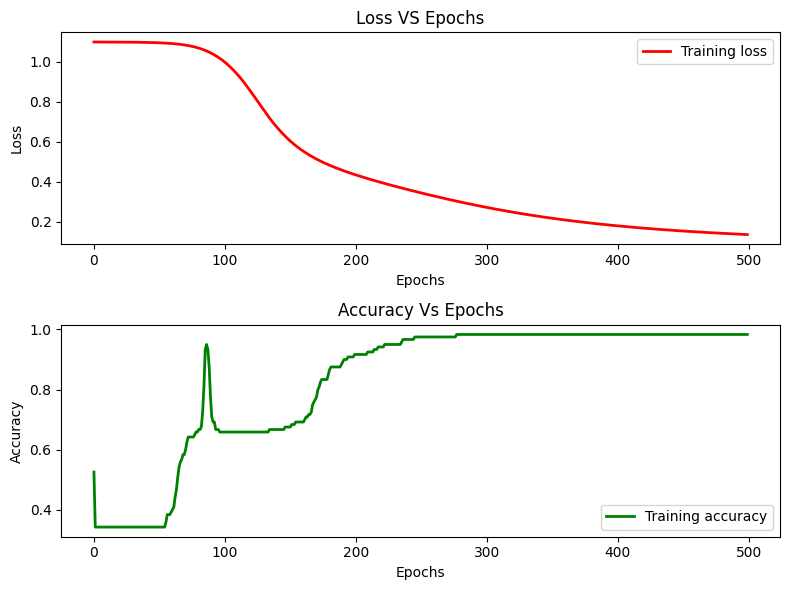

In [19]:
fig,ax=plt.subplots(2,1,figsize=(8,6))
ax[0].plot(nn_iris.loss_history,
           label='Training loss',
           color='red',
           linewidth=2)
ax[0].set_title('Loss VS Epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(nn_iris.accuracy_history,
           label='Training accuracy',
           color='green',
           linewidth=2)
ax[1].set_title('Accuracy Vs Epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()

plt.savefig('../Images/Training_metrics.png')
plt.show()



In [20]:
import os
print(os.getcwd())

g:\My Drive\REAL PROJECTS\IRIS_MLP_APP\Notebooks


Save Trained Model

In [23]:
import pickle
with open ('../Model/iris_mlp.pkl','wb') as file:
    pickle.dump(nn_iris,file)

print('Model saved successfully')


Model saved successfully


In [22]:
print('hello')

hello
